# Práctica 2 CAN-GIA. Introducción a SymPy 

### Introducción a SymPy

Además de las variables numéricas, existen las variables simbólicas que permiten calcular
límites, derivadas, integrales, etc., como se hace habitualmente en las clases de matemáticas.
Para poder hacer estas operaciones, es preciso tener instalada la librería **SymPy**. En https://docs.SymPy.org/latest/index.html tenéis más información sobre este módulo.

A diferencia del módulo **NumPy**, el módulo **SymPy** no trabaja con una estructura de datos basada en números sino que trabaja con objetos que poseen atributos y métodos que tratan de reproducir el comportamiento matemático de las variables, funciones, ecuaciones, etc. con las que se trabaja habitualmente en cálculo diferencial e integral.


### Objetivos:

- Uso de variables simbólicas
- Hipótesis sobre las variables 
- Manipulación de expresiones simbólicas
- Representación gráfica de funciones mediante SymPy


## Carga del módulo
El módulo **SymPy** se puede instalar usando la herramienta `pip` (!pip3 -q install SymPy) o `conda` si se emplea otro entorno de trabajo. Para poder utilizar el módulo **SymPy**, una vez instalado, lo importamos mediante:

In [ ]:
import sympy as sp

## Variables simbólicas
Para trabajar en modo simbólico es necesario definir variables simbólicas, para lo cual empleamos la función `sp.Symbol`. Veamos algunos ejemplos:

In [ ]:
x = sp.Symbol('x') # define la variable simbólica x
y = sp.Symbol('y') # define la variable simbólica y
expresion1 = 3*x + 5*y # define la expresion simbólica expresion1. 
print(expresion1)

a, b, c = sp.symbols('a:c') # define como simbólicas las variables a, b, c.
expresion2 = a**3 + b**2 + c
print(expresion2)

Debemos de tener claro que las variables `x` o `y` que acabamos de definir no son números, ni tampoco pertenecen a los objetos definidos con  **NumPy**. Todas las variables simbólicas son objetos de la clase `sp.Symbol` y sus atributos y métodos son completamente diferentes a los que aparecían en las variables numéricas y vectores de **NumPy**:

In [ ]:
print(type(x))

Con **SymPy** se pueden definir constantes enteras o números racionales (todas de forma simbólica) usando los comandos `sp.Integer` o `sp.Rational`, respectivamente. Por ejemplo, podemos definir la constante simbólica $1/3$. Si hacemos lo mismo con números representados por defecto en Python, obtendríamos resultados muy diferentes. Observa también la diferencia que existe entre el tipo de dato asignado en el espacio de trabajo

In [2]:
import sympy as sp

a = sp.Rational('1/3')
b = sp.Integer('1')/sp.Integer('3')
c = 1/3
d = 1.0/3.0
print(a)
print(b)
print(c)
print(d)
print(type(a))
print(type(c))

1/3
1/3
0.3333333333333333
0.3333333333333333
<class 'sympy.core.numbers.Rational'>
<class 'float'>


La función `float`, una vez hechos todos los cálculos simbólicos, permite obtener el **valor numérico**.

In [ ]:
a = 2
print(a)
b = 3.0
c = a/b
e = float(c)
print(type(a))
print(type(c))
print(c)
print('{0:.15f}'.format(e))

Algunas constantes simbólicas de uso frecuente, como los números $\pi$ y $e$, están disponibles en **SymPy**. Para operar con variables o constantes simbólicas, debemos emplear funciones que sean capaces de manipular este tipo de objetos, todas ellas implementadas en el módulo **SymPy** (por ejemplo, `sp.sin`, `sp.cos`, `sp.log`, `sp.exp`,`sp.sqrt`,etc).

In [ ]:
p = sp.pi # definición de la constante pi
print('cos(pi) = ',sp.cos(p))
p1 = sp.sqrt(p) 
print('exp(sqrt(pi)) = ',sp.exp(p1))

e = sp.E # definición del número e
print('ln(e) = ',sp.log(e))  # observa que log calcula el neperiano

## Hipótesis sobre las variables

Cuando se define una variable simbólica, se le puede asignar cierta información adicional sobre el tipo de valores que puede alcanzar, o las hipótesis que se le van a aplicar. Por ejemplo, podemos decidir antes de hacer cualquier cálculo si la variable toma valores enteros o reales, si es positiva o negativa, mayor que un cierto número, etc. Este tipo de información se añade en el momento de la definición de la variable simbólica como un argumento opcional.

In [ ]:
x = sp.Symbol('x', nonnegative = True) # la raíz cuadrada de un número no negativo es real
y = sp.sqrt(x)
print(y.is_real)   # la salida de una variable lógica es True o None

x = sp.Symbol('x', integer = True) # la potencia de un número entero es entera
y = x**sp.S(2)
print(y.is_integer)

a = sp.Symbol('a')
b = sp.sqrt(a)
print(b.is_real)

a = sp.Symbol('a')
b = a**sp.S(2)
print(b.is_integer)

Puesto que los cálculos simbólicos son consistentes en **SymPy**, también se pueden hacer comprobaciones sobre si algunas desigualdades son ciertas o no, siempre y cuando sean compatibles con las hipótesis que se hagan al definir las variables simbólicas.

In [ ]:
x = sp.Symbol('x', real = True)
p = sp.Symbol('p', positive = True)
q = sp.Symbol('q', real = True)
y = sp.Abs(x) + p #  valor absoluto
z = sp.Abs(x) + q
print(y > 0)
print(z > 0)

## Manipulación de expresiones simbólicas

De la misma forma que el módulo **SymPy** permite definir variables simbólicas, también podemos definir expresiones matemáticas a partir de éstas y manipularlas, factorizándolas, expandiéndolas,  o imprimiéndolas  como lo haríamos con lápiz y papel

In [ ]:
x,y = sp.symbols('x,y', real=True)
expr = (x-3)*(x-3)**2*(y-2)
expr_long = sp.expand(expr) # Expandir expresión

print(expr_long) # Imprimir de forma estándar
print()
sp.pprint(expr_long) # Imprimir de forma semejante a con lápiz y papel
print()

expr_short = sp.factor(expr)
print(expr_short) # Factorizar expresión
print()

expr = -3+(x**2-6*x+9)/(x-3)
expr_simple = sp.simplify(expr) # Simplificar expresión
sp.pprint(expr)
print(expr_simple)

Dada una expresión en **SymPy**, también se puede manipular, sustituyendo unas variables simbólicas por otras o reemplazando las variables simbólicas por constantes. Para hacer este tipo de sustituciones se emplea la función `subs` y los valores a utilizar en la sustitución vienen definidos por un diccionario de Python:

In [3]:
import sympy as sp
x,y = sp.symbols('x,y', real=True)
expr = x*x + x*y + y*x + y*y
res = expr.subs({x:1, y:2}) # Sustitución de las variables simbólicas por constantes
print(res)

expr_sub = expr.subs({x:1-y}) # Sustitución de variable simbólica por una expresión
sp.pprint(expr_sub)
print(sp.simplify(expr_sub))

9
 2                        2
y  + 2⋅y⋅(1 - y) + (1 - y) 
1


### **Ejercicio 1** ###
Define la expresión simbólica dada por la suma de los términos siguientes:
$$
a+a^2+a^3+a^5,
$$
donde $a$ es una variable real arbitraria. Obtén el valor numérico de dicha expresión de dos formas distintas cuando a = 3.4.

In [5]:
# TU CÓDIGO AQUÍ
import sympy as sp
a = sp.symbols('a')
expr = a + a**2 + a**3 + a**5
expr_sub = expr.subs({a:3.4})
#1
print(expr_sub)
#2
print(sp.simplify(expr_sub))


508.618240000000
508.618240000000


### Solve ###
El comando `solve` nos permite resolver una ecuación o un sistema de ecuaciones como puedes ver a continuación:

In [ ]:
x = sp.symbols('x')
ec1 = sp.exp(x+1) - 5
sol1 = sp.solve(ec1,x)
print(sol1)
print(float(sol1[0]))

In [ ]:
# Importar la librería SymPy
import sympy as sp

# Definir las variables simbólicas
x, y = sp.symbols('x y')

# Definir el sistema de ecuaciones
# Ejemplo:
# 2x + 3y = 6
# 3x - 4y = -12
ec1 = sp.Eq(2*x + 3*y, 6)
ec2 = sp.Eq(3*x - 4*y, -12)

# Resolver el sistema
solucion = sp.solve((ec1, ec2), (x, y))

# Mostrar la solución
display(solucion)


### **Ejercicio 2** ###  
Construye una expresión cuyas raíces son $ r1 = 2.3 $ y $ r2 = -5.3$. Desarrolla la expresión y comprueba mediante el comando `solve` sus raíces.

In [13]:
import sympy as sp

# 1. Definimos la variable simbólica
x = sp.symbols('x')

# 2. Construimos la expresión a partir de las raíces dadas
r1 = 2.3
r2 = -5.3
expresion = (x - r1) * (x - r2)

# 3. Desarrollamos la expresión
expresion_desarrollada = sp.expand(expresion)
print("Expresión desarrollada:", expresion_desarrollada)

# 4. Comprobamos las raíces mediante el comando solve
raices = sp.solve(expresion_desarrollada, x)
print("Raíces calculadas con solve:", raices)

Expresión desarrollada: x**2 + 3.0*x - 12.19
Raíces calculadas con solve: [-5.30000000000000, 2.30000000000000]


## Funciones con Sympy
Debemos diferenciar expresión de función. El comando **lambda** nos permite el paso de una a otra.

In [11]:




x = sp.Symbol('x',real=True)           # Se define la variable simbólica x
exprf = x**2+sp.exp(-3*x)+1
f = sp.Lambda((x),exprf) # Se define la función f
display(' expresion  ',exprf)
display('evaluar la expresion en 3', exprf.subs({x:3}))
display(' funcion  ',f)
display(' evaluar la funcion f(3)= ',f(3))

' expresion  '

x**2 + 1 + exp(-3*x)

'evaluar la expresion en 3'

exp(-9) + 10

' funcion  '

Lambda(x, x**2 + 1 + exp(-3*x))

' evaluar la funcion f(3)= '

exp(-9) + 10

## Representación gráfica con SymPy ##

Vemos ahora una manera alternativa de representar funciones reales de una variable real usando el módulo **SymPy**.
Representamos a continuación la parábola $y=x^2$, para $x\in[-3,3]$, y la función signo en el intervalo $[-5,5]$.

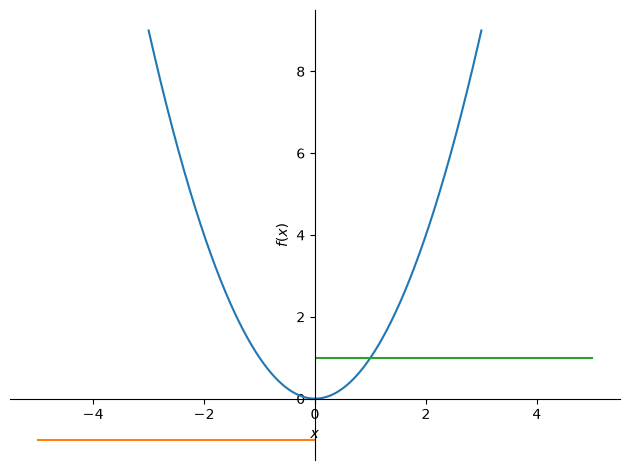

In [7]:
from sympy import symbols
from sympy import sign
from sympy.plotting import plot

x = symbols('x')

plot((x**2, (x, -3, 3)), (sign(x), (x, -5, -0.01)),(sign(x), (x, 0.01, 5)))

### **Ejercicio 3** ###
Emplea SymPy para representar en la misma gráfica la función $$ g(x) = \cos(kx)$$  para tres valores de $k$ distintos.

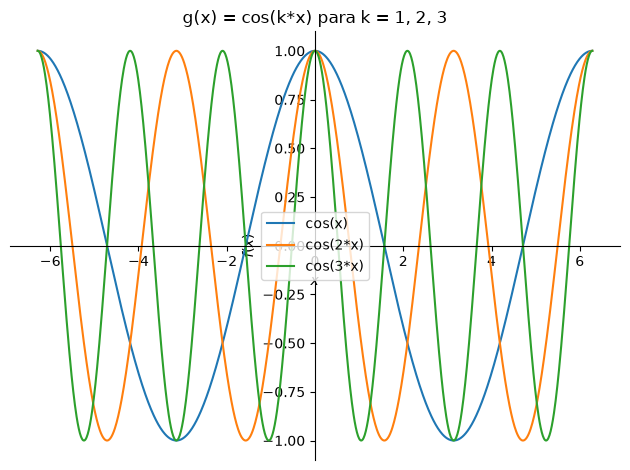

In [9]:
#TU CÓDIGO AQUÍ
import sympy as sp
from sympy.plotting import plot

# Definir la variable simbólica x
x = sp.symbols('x')

# Definir la función para tres valores distintos de k (ej. k = 1, k = 2, k = 3)
g1 = sp.cos(1 * x)
g2 = sp.cos(2 * x)
g3 = sp.cos(3 * x)

# Representar las tres funciones en la misma gráfica
plot(g1, g2, g3, (x, -2*sp.pi, 2*sp.pi), title="g(x) = cos(k*x) para k = 1, 2, 3", legend=True)



### Construimos con SymPy. Dibujamos con NumPy
Este código primero define una función polinómica usando **SymPy**. Luego, `lambdify` convierte la función en una función **NumPy** que puede ser evaluada en una matriz de valores x. Finalmente, se grafica la función usando **matplotlib**.

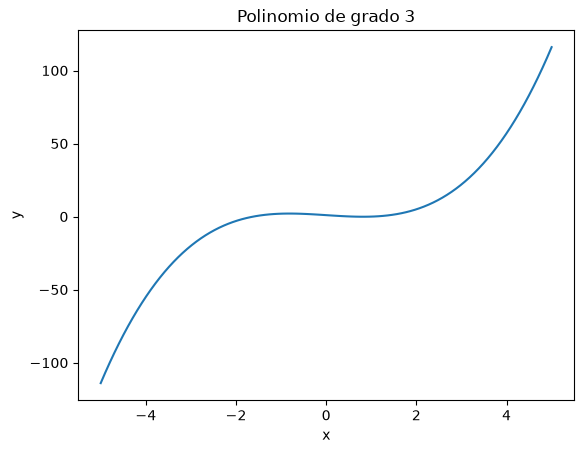

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, lambdify

# Definimos la función cúbica
x = symbols('x')
func = x**3 - 2*x + 1

# Convertimos la función en una función NumPy
func_np = lambdify(x, func, 'numpy')

# Creamos el rango de valores para x
x_vals = np.linspace(-5, 5, 100)

# Evaluamos la función en los valores de x
y_vals = func_np(x_vals)

# Creamos el gráfico
plt.plot(x_vals, y_vals)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polinomio de grado 3')
plt.show()


In [ ]:
Podemos construir una función a trozos mediante Sympy y, a continuación, al igual que el ejemplo anterior dibujarla con numpy.

Eq(f(x), Piecewise((x**2, x < -1), (x + 1, x <= 2), (sin(x), True)))

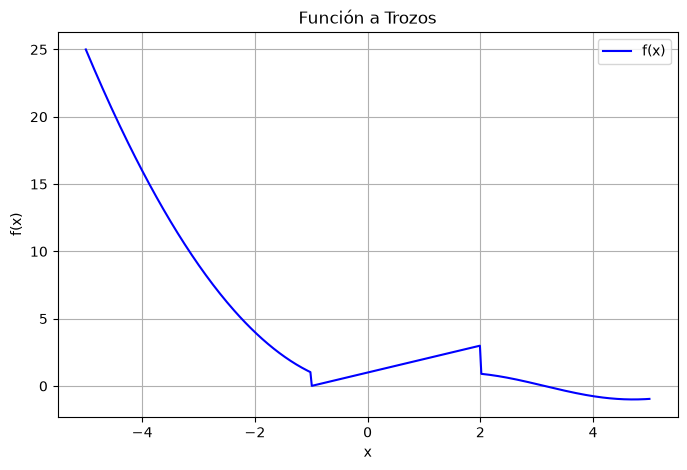

In [6]:
# Importar librerías necesarias
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

# Definir la variable simbólica
x = sp.symbols('x')

# Definir la función a trozos
f = sp.Piecewise(
    (x**2, x < -1),
    (x + 1, (x >= -1) & (x <= 2)),
    (sp.sin(x), x > 2)
)

# Mostrar la función simbólicamente
display(sp.Eq(sp.Symbol('f(x)'), f))

# Convertir a función numérica para graficar
f_func = sp.lambdify(x, f, 'numpy')

# Crear valores de x y evaluar
x_vals = np.linspace(-5, 5, 400)
y_vals = f_func(x_vals)

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label='f(x)', color='blue')
plt.title('Función a Trozos')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()


### Ejercicio 4. La función sigmoide  

La función 
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$
es ampliamente utilizada en redes neuronales como función de activación, especialmente en tareas de clasificación binaria.
Construye la función con Sympy y haciendo uso del comando lambdify representa su gráfica en $[-10,10]$.

In [ ]:
# TU CÓDIGO AQUÍ